# Nonlinear model for velocity divergence power spectrum
### Author: Francesca Lepori

The model predicts the quantity:

$P_{\theta\theta}(k, z) / (\mathcal{H}(z) f(z))^2,$

which coincides with the matter power spectrum in linear theory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from velocity_model import (
    read_gevolution_outputs,
    Pk_theta_nl_mod,
    get_pktheta_interpolator
)

Derivatives with respect to h computed successfully.


In [2]:
from classy import Class

#Redshift and scales to evaluate the model
z_plot = 0.4
k_array = np.logspace(-2, 1, 100)

# Fiducial cosmology
h_ref = 0.67556
omega_cdm_ref = 0.12038

# Test cosmology parameters
h_test = 0.72
omega_cdm_test = 0.13

# Common parameters for both fiducial and test cosmologies
A_s_ref = 2.215e-9
omega_b = 0.022032
A_s_ref = 2.215e-9
n_s = 0.9619
k_pivot = 0.05
T_cmb = 2.7255
N_ur = 3.046

params_fid = {
        'omega_b': omega_b,
        'k_pivot': k_pivot,
        'n_s': n_s,
        'T_cmb': T_cmb,
        'N_ur': N_ur,
        'h': h_ref,
        'omega_cdm': omega_cdm_ref,
        'A_s': A_s_ref,
        'output': 'mPk, dTk, vTk',
        'lensing': 'no',
        'z_pk': '0.0, 0.1, 1.0, 2.0, 3.0',
        'P_k_max_h/Mpc': 300.0
        }

params_omega_cdm= params_fid.copy()
params_omega_cdm["omega_cdm"] = omega_cdm_test


params_test_cosmo = params_fid.copy()
params_test_cosmo["omega_cdm"] = omega_cdm_test
params_test_cosmo["h"] = h_test



# --- Evaluate linear P_theta for test cosmology ---
cosmo_test = Class()
cosmo_test.set(params_test_cosmo)
cosmo_test.compute()
    
Pk_theta_lin = np.array([cosmo_test.pk_lin(k, z_plot) for k in k_array])

#needed to normalize simulated power spectra
Hconf_test = cosmo_test.Hubble(z_plot)/(1.0+z_plot)/h_test
f_growth_test = cosmo_test.scale_independent_growth_factor_f(z_plot)

cosmo_test.struct_cleanup()
cosmo_test.empty()

# --- Compute interpolators ---
pktheta_fid_interp = get_pktheta_interpolator(params_fid, z_vals=np.linspace(0, 2.5, 50))
pktheta_omega_cdm_interp = get_pktheta_interpolator(params_omega_cdm, z_vals=np.linspace(0, 2.5, 50))

# --- Evaluate non-linear P_theta using evolution mapping ---
Pk_theta_nl_noder = Pk_theta_nl_mod(k_array, z_plot, h=h_test, omega_cdm=omega_cdm_test, pktheta_fid_interp=pktheta_fid_interp, pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
                              A_s_ref=A_s_ref, omega_cdm_ref=omega_cdm_ref, h_ref=h_ref, deriv=False)

Pk_theta_nl = Pk_theta_nl_mod(k_array, z_plot, h=h_test, omega_cdm=omega_cdm_test, pktheta_fid_interp=pktheta_fid_interp, pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
                              A_s_ref=A_s_ref, omega_cdm_ref=omega_cdm_ref, h_ref=h_ref, deriv=True)

print("Model evaluation complete.")

Model evaluation complete.


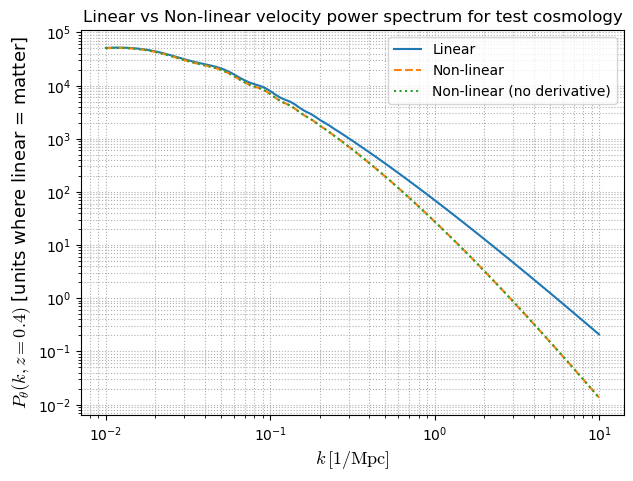

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams['mathtext.fontset'] = 'cm'

# --- Plot ---
plt.figure(figsize=(7,5))
plt.loglog(k_array, Pk_theta_lin, label='Linear', color='C0')
plt.loglog(k_array, Pk_theta_nl, label='Non-linear', color='C1', linestyle='--')
plt.loglog(k_array, Pk_theta_nl_noder, label='Non-linear (no derivative)', color='C2', linestyle=':')

plt.xlabel(r'$k\,[1/\mathrm{Mpc}]$', fontsize=13)
plt.ylabel(r'$P_\theta(k, z={})$ [units where linear = matter]'.format(z_plot), fontsize=13)
plt.title('Linear vs Non-linear velocity power spectrum for test cosmology')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

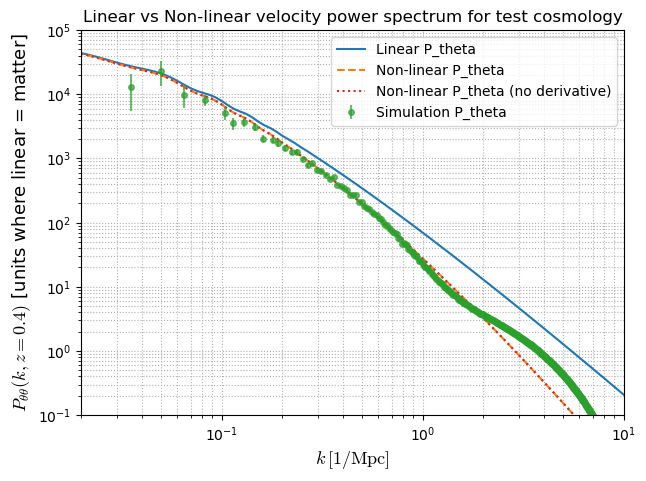

In [8]:
path_to_gevolution_outputs = 'sim-data/cosmo-test-Asfid/'

results_test = read_gevolution_outputs(path_to_gevolution_outputs, h_test)

# Check that the requested redshift exists
if z_plot not in results_test:
    raise ValueError(
        f"Redshift z = {z_plot} is not available in the simulation dataset. "
        f"Available redshifts are: {sorted(results_test.keys())}"
    )

k_sim = results_test[z_plot]["k_vort"]*h_test
Pk_theta_sim = results_test[z_plot]["Pk_theta"] / (Hconf_test * f_growth_test)**2/h_test**3
Nk_theta_sim = results_test[z_plot]["Nk_theta"]

sigma_pktheta = np.sqrt(2.0 / Nk_theta_sim) * Pk_theta_sim

# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(k_array, Pk_theta_lin, label='Linear P_theta', color='C0')
plt.plot(k_array, Pk_theta_nl, label='Non-linear P_theta', color='C1', linestyle='--')
plt.plot(k_array, Pk_theta_nl_noder, label='Non-linear P_theta (no derivative)', color='C3', linestyle=':')

plt.errorbar(k_sim, Pk_theta_sim, yerr=sigma_pktheta, fmt='o', label='Simulation P_theta', color='C2', markersize=4, alpha=0.7)

#set log scale for y-axis
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.02, 10.0)
plt.ylim(1e-1, 1e5)
plt.xlabel(r'$k\,[1/\mathrm{Mpc}]$', fontsize=13)

plt.ylabel(r'$P_{\theta\theta}(k, z='+str(z_plot)+')$ [units where linear = matter]', fontsize=13)
plt.title('Linear vs Non-linear velocity power spectrum for test cosmology')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

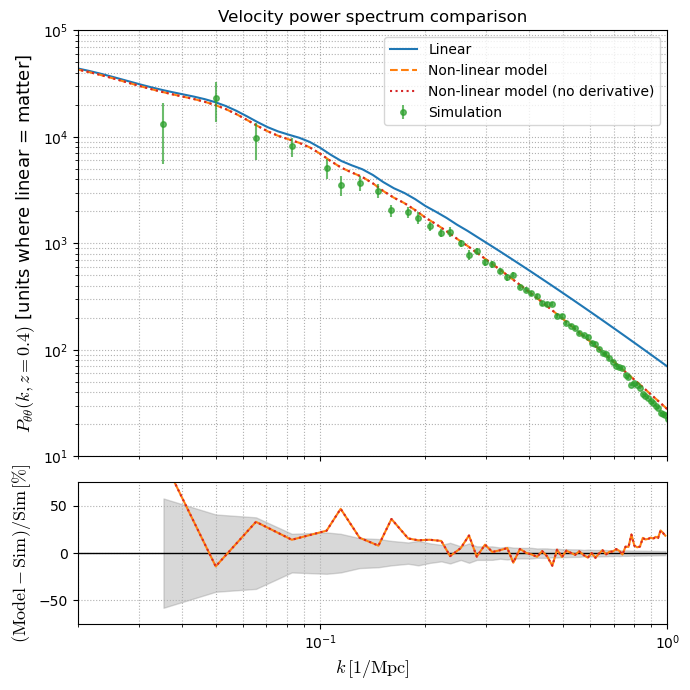

In [9]:
kmax_sim = 1.0
mask = k_sim <= kmax_sim

k_sim_cut = k_sim[mask]
Pk_theta_sim_cut = Pk_theta_sim[mask]
sigma_pktheta_cut = sigma_pktheta[mask]

# --- Interpolate model onto simulation k if needed ---
# (only needed if k_array != k_sim)
Pk_theta_nl_on_sim = np.interp(
    k_sim_cut,
    k_array,
    Pk_theta_nl
)

Pk_theta_nl_noder_on_sim = np.interp(
    k_sim_cut,
    k_array,
    Pk_theta_nl_noder
)

# --- Relative difference ---
rel_diff = (Pk_theta_nl_on_sim - Pk_theta_sim_cut) / Pk_theta_sim_cut
rel_diff_noder = (Pk_theta_nl_noder_on_sim - Pk_theta_sim_cut) / Pk_theta_sim_cut
# --- Figure with two panels ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# =======================
# Top panel: Power spectra
# =======================
ax1.plot(k_array, Pk_theta_lin, label='Linear', color='C0')
ax1.plot(k_array, Pk_theta_nl, label='Non-linear model', color='C1', linestyle='--')
ax1.plot(k_array, Pk_theta_nl_noder, label='Non-linear model (no derivative)', color='C3', linestyle=':')

ax1.errorbar(
    k_sim, Pk_theta_sim, yerr=sigma_pktheta,
    fmt='o', label='Simulation',
    color='C2', markersize=4, alpha=0.7
)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.02, 1.0)
ax1.set_ylim(1e1, 1e5)

ax1.set_ylabel(r'$P_{\theta\theta}(k, z='+str(z_plot)+')$ [units where linear = matter]', fontsize=13)
ax1.set_title('Velocity power spectrum comparison')
ax1.legend()
ax1.grid(True, which='both', ls=':')

# =======================
# Bottom panel: Relative difference
# =======================
ax2.axhline(0, color='k', linestyle='-', linewidth=1)

ax2.plot(k_sim_cut, 100*rel_diff, color='C1')
ax2.fill_between(
    k_sim_cut,
    -100.0*sigma_pktheta_cut / Pk_theta_sim_cut,
    100.0*sigma_pktheta_cut / Pk_theta_sim_cut,
    color='gray', alpha=0.3, label='Simulation error'
)

ax2.plot(k_sim_cut, 100*rel_diff_noder, color='C3', linestyle=':', label='Non-linear model (no derivative)')

ax2.set_xscale('log')
ax2.set_xlim(0.02, 1.0)

ax2.set_xlabel(r'$k\,[1/\mathrm{Mpc}]$', fontsize=13)
ax2.set_ylabel(r'$(\mathrm{Model - Sim})/\mathrm{Sim}\,[\%]$', fontsize=13)
ax2.grid(True, which='both', ls=':')

ax2.set_ylim(-75, 75)

plt.tight_layout()
plt.show()